# dN/dR Distributions from sample galaxy SEDs

Purpose of this notebook is to look at how the dN/dR profile changes when accounting for real galaxy SEDs, as compared to a flat dNdR distribution which was assumed in some previous analysis. 
Also examines a set of stellar SEDs. 

Additional plotting cells to look at the relationship between in-band slope and mean refraction angle E(R).



In [1]:
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt
import galsim
import os
from astropy.table import Table

from astropy.modeling.models import BlackBody


def BB(wave, temp, scale):
    temp = temp * u.K
    wave = wave * u.AA
    scale = scale * u.erg / (u.cm**2 * u.s * u.AA * u.sr)

    bb = BlackBody(temperature = temp, scale = scale)
    return bb(wave).value


0
0.0
10
6.675811986954415
20
13.780062716699556
30
21.858718570699306
45
37.860411152800545
70
104.02062473358743


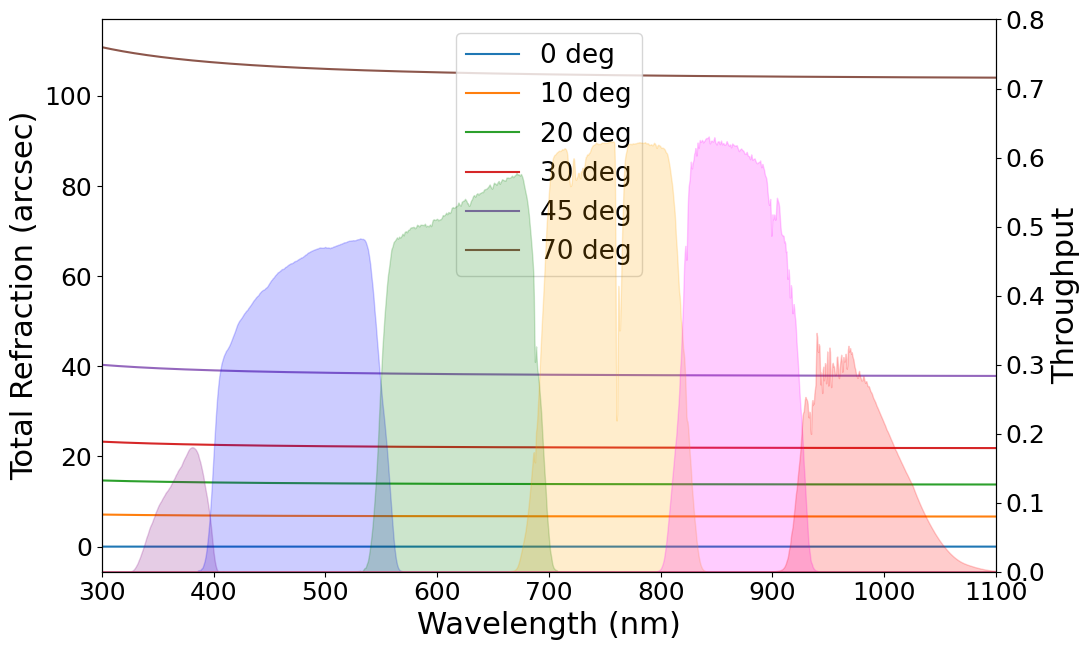

In [2]:
#checking my understanding of the dcr.get_refraction function by 
#recreating the plot 1 from the Impact of Atmospheric Chromatic Effects on Weak Lensing Measurements (Meyers and Burchat, 2018)
zeniths = [0,  10, 20, 30, 45, 70]
# zeniths = [35]
dwvl = 0.5
wavelengths = np.arange(290, 1160, dwvl)

fig, ax1 = plt.subplots(figsize = (11, 6.6))

filters = ['total_u.dat','total_g.dat','total_r.dat','total_i.dat','total_z.dat','total_y.dat']
colors = {'u' : 'purple', 'g':'blue', 'r': 'green', 'i': 'orange', 'z' : 'magenta', 'y' : 'red'}
script_dir = os.getcwd()
folder = os.path.join(script_dir, 'filter_files/')

ax2 = ax1.twinx()
for i, filter_ in enumerate(filters):
    path = folder + filter_
    data = np.loadtxt(path).T
    band = list(colors.keys())[i]
    ax2.fill_between(data[0], data[1], np.zeros(len(data[1])), label = filter_, alpha = 0.2, color = colors[band])


# Atmospheric Conditions

# SEA LEVEL
# pressure=101 #kPa
# temperature= 288.15 # K
# H2O_pressure= 1.067 # kPa

# RUBIN OBSERVATORY (defaults)
pressure=69.328 # kPa
temperature= 293.15 # K
H2O_pressure= 1.067 # kPa




for zenith in zeniths:
    refraction = galsim.dcr.get_refraction(
            wavelengths,
            zenith_angle=zenith * galsim.degrees,
            pressure=pressure,  # kPa
            temperature=temperature,  # K
            H2O_pressure=H2O_pressure,  # kPa
            ) * 180 * 3600 / np.pi  #convert from radians to arcsec
    
    refraction_0 = galsim.dcr.get_refraction(
            700,
            zenith_angle=zenith * galsim.degrees,
            pressure=pressure,  # kPa
            temperature=temperature,  # K
            H2O_pressure=H2O_pressure,  # kPa
            ) * 180 * 3600 / np.pi #convert from radians to arcsec

    
    dR_dwvl = (refraction[1:] - refraction[0:-1])/dwvl
    wavelengths_midpoints = wavelengths[0:-1] + dwvl/2
    
    ax1.plot(wavelengths, refraction , label = f'{zenith} deg') #- refraction_0
    # plt.plot(wavelengths_midpoints, dR_dwvl, '--')
    print(zenith)
    print(refraction[-1])


ax1.set_xlim(300, 1100)
# ax1.set_ylim(-0.5, 1)
ax1.set_xlabel('Wavelength (nm)', fontsize = 22)
ax1.set_ylabel('Relative Refraction (arcsec)', fontsize = 22)
ax1.set_ylabel('Total Refraction (arcsec)', fontsize = 22)
ax1.legend(fontsize = 19)
ax1.tick_params(labelsize=18)  


ax2.set_ylim(0, 0.8)
ax2.set_ylabel('Throughput', fontsize = 22)
ax2.tick_params(labelsize=18)  

plt.tight_layout()

# fig.savefig('refrac_filterthroughput.pdf')

In [3]:
#Load sample stellar SEDs
file_paths = 'starSED_files_list.txt'

#These need to be divided into two populations: kurucz and phoSimMLT
#I'm not sure why these look so different or whether they come from different simulations

wave_ku = []
flux_ku = []

wave_pho = []
flux_pho = []

with open(file_paths) as f:
    star_files = f.read().splitlines()  
    for file in star_files:
        file = 'starSEDs' + file
        t = Table.read(file, format='ascii')

        waveS = np.array(t['col1'])
        fluxS = np.array(t['col2'])
        mask = (waveS > 250)  * (waveS < 1200)

        waveS = waveS[mask]
        fluxS = fluxS[mask]

        if file.__contains__('phoSimMLT'):
            flux_pho.append(fluxS)
            if len(wave_pho) < 2:
                wave_pho = waveS
        elif file.__contains__('kurucz'):
            flux_ku.append(fluxS)
            if len(wave_ku) < 2:
                wave_ku = waveS



# for i in range(len(flux_ku)):
#     plt.plot(wave_ku, flux_ku[i], 'k-', alpha = 0.01)
# plt.xlabel('wavelength')
# plt.ylabel('Flux') 
# plt.title('Kurucz SEDs')
# plt.legend()
# plt.show()
# plt.close()

# for i in range(len(flux_pho)):
#     plt.plot(wave_pho, flux_pho[i],'k-', alpha = 0.01)
# plt.xlabel('wavelength')
# plt.ylabel('Flux') 
# plt.title('phoSimMLT SEDs')
# plt.legend()
# plt.show()






#### Before applying the filters, removed leakage from the filters by removing anything below a 0.001 throughput:

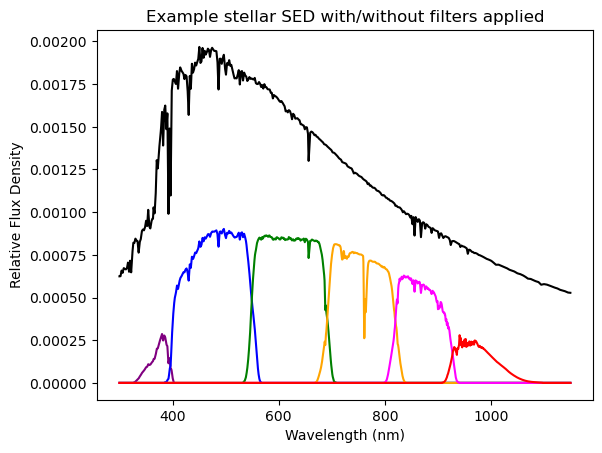

In [4]:
#Open the SEDs and apply the filters

from scipy.interpolate import interp1d
from utils import apply_filter

# def apply_filter(wvl, data, band = 'g', rm_leakage = True):
#     '''
#     wvl - a list of the wavelengths in angstroms
#     data - a N x M list of SEDs, N = number of SEDs, M = len of wvl
#     returns data with the band filter applied to each SED
#     '''
#     if band == 'all':
#         filtered_data = {}
#         for band in 'ugrizy':
#             filter_file = f'filter_files/total_{band}.dat'
#             filter_band = np.loadtxt(filter_file).T #filter_band[0] -> wavelengths, filter_band[1] -> filter pass fraction

#             # remove filter leakage: set lower bound of filter to 0.001 throughput
#             if rm_leakage:
#                 leakage_mask = filter_band[1] < 0.001
#                 filter_band[1][leakage_mask] = np.zeros(np.sum(leakage_mask))
            
#             func = interp1d(filter_band[0], filter_band[1])
#             SED_filter = func(wvl)
#             filtered_data[band] = data * SED_filter
#         return filtered_data
#     else:
#         filter_file = f'filter_files/total_{band}.dat'
#         filter_band = np.loadtxt(filter_file).T #filter_band[0] -> wavelengths, filter_band[1] -> filter pass fraction

#         # remove filter leakage: set lower bound of filter to 0.001 throughput
#         if rm_leakage:
#             leakage_mask = filter_band[1] < 0.001
#             filter_band[1][leakage_mask] = np.zeros(np.sum(leakage_mask))
        
#         func = interp1d(filter_band[0], filter_band[1])
#         SED_filter = func(wvl)
#         return data * SED_filter
    
def normalize_distributions(x_array, distributions, append_average = False):
    """
    Normalize each SED so its integral over x_array is 1.
    Parameters
    ----------
    x_array : (M,) array
        Wavelength grid (nm or Angstrom).
    distributions : (N, M) array
        SEDs, N spectra by M wavelengths.
    Returns
    -------
    normed : (N, M) array
        Normalized SEDs.
    """
    # Compute integral for each SED
    integrals = np.trapezoid(distributions, x_array, axis=1)
    # Avoid division by zero
    integrals[integrals == 0] = 1.0
    normed = distributions / integrals[:, np.newaxis]
    

    if append_average:
        return np.vstack([normed, np.median(normed, axis = 0)])
    else:
        return np.array(normed)


# ---- Get stellar SEDs ----
stellar_wvl = np.array(wave_ku)
stellar_SEDs = np.array(flux_ku)
mask = (stellar_wvl > 300) * (stellar_wvl < 1150)
stellar_wvl = stellar_wvl[mask]
stellar_SEDs = stellar_SEDs[:, mask]

# increase wavelength resolution to capture filter details:
func = interp1d(stellar_wvl, stellar_SEDs)
stellar_wvl_temp = np.linspace(min(stellar_wvl), max(stellar_wvl), 8500)
stellar_wvl =stellar_wvl_temp
stellar_SEDs = func(stellar_wvl_temp)

# Normalize the SEDs for comparison purposes and append the "median" SED
stellar_SEDs = normalize_distributions(stellar_wvl, stellar_SEDs, append_average = True)




# ---- Get galaxy SEDs (file contains 1000 randomly sampled SEDs with magnitudes less than 26) ----
file = '1000SEDs.txt'
data = np.loadtxt(file)
wvl = data[0]
SEDs = data[1:]

#remove wavelengths > 1150 because that's where our filters cut off
mask = wvl < 1150
wvl = wvl[mask]
SEDs = SEDs[:, mask]

# increase wavelength resolution to capture filter details:
func = interp1d(wvl, SEDs)
wvl_temp = np.linspace(min(wvl), max(wvl), 8500)
wvl = wvl_temp
SEDs = func(wvl_temp)

# Normalize the SEDs for comparison purposes and append the median SED
SEDs = normalize_distributions(wvl, SEDs, append_average = True)



# --- Set up a flat SED for testing
flatSED = np.array([np.ones(len(wvl))])

flatSED = normalize_distributions(wvl, flatSED)



    
# --- Apply filters to SEDs ----
filter_labels = ['u', 'g', 'r', 'i', 'z', 'y']


filtered_data = {}
stellar_filtered_data = {}
flat_filtered = {}

i = 0 #choose the index of one of the SEDs to plot (i = -1 for the median SED)

plt.plot(wvl, stellar_SEDs[i], 'k', label = f'SED index: {i}')

for band in filter_labels:
    filtered_data[band]= apply_filter(wvl, SEDs, band)
    stellar_filtered_data[band]= apply_filter(stellar_wvl, stellar_SEDs, band)
    flat_filtered[band] = apply_filter(wvl, flatSED, band)
    plt.plot(wvl, stellar_filtered_data[band][i], color = colors[band])

plt.title('Example stellar SED with/without filters applied')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Relative Flux Density')
# plt.legend()
plt.show()

/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


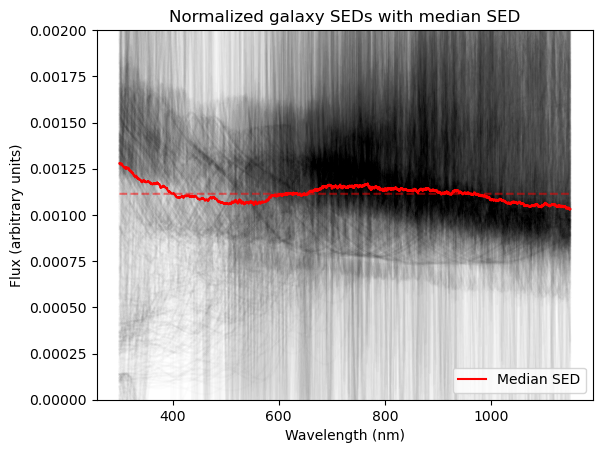

In [5]:
#Examine the average/median galaxy SED behavior

for SED in SEDs[:-1]:
    plt.plot(wvl, SED, 'k-', alpha = 0.01)

average_SED = SEDs[-1]
plt.plot(wvl, average_SED, 'r-', label = 'Median SED')
plt.plot(wvl, np.ones(len(wvl))*np.mean(average_SED), 'r--', alpha = 0.5)
plt.title('Normalized galaxy SEDs with median SED')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Flux (arbitrary units)')
plt.legend()
plt.ylim(0, 0.002)
plt.show()
plt.close()



In [6]:
# Get quick stellar temperature estimate from Wien's law 

from scipy.ndimage import median_filter

C2 = 1.438777e7  # hc/k in nm*K
WIEN_CONST = 2.897771955e6  # nm*K

def smooth_and_peak_many(wl_nm, fluxes, kernel=31):
    """
    Vectorized peak wavelength finder for many spectra.
    
    Parameters
    ----------
    wl_nm : (M,) array
        Wavelength grid (same for all spectra).
    fluxes : (N, M) array
        Flux values, N spectra by M wavelengths.
    kernel : int
        Median filter kernel size (odd integer).
    
    Returns
    -------
    wl_peaks : (N,) array
        Peak wavelength (nm) for each spectrum after smoothing.
    idx_peaks : (N,) array
        Index of the peak for each spectrum.
    """
    if kernel % 2 == 0:
        kernel += 1  # enforce odd size
    
    # Smooth along wavelength axis (axis=1)
    smoothed = median_filter(fluxes, size=(1, kernel), mode='nearest')
    
    # Find argmax per spectrum
    idx_peaks = np.nanargmax(smoothed, axis=1)
    wl_peaks = wl_nm[idx_peaks]
    
    return wl_peaks

def T_from_wien_peak(wl_peak_nm):
    return WIEN_CONST / wl_peak_nm

stellar_SED_peaks = smooth_and_peak_many(stellar_wvl, stellar_SEDs[:-1], kernel=31) #exclude the median SED at the end
stellar_temps = T_from_wien_peak(stellar_SED_peaks)

## Apply refraction effects at a chosen zenith and atmospheric conditions

At a given zenith, there is a 1-to-1 mapping of wavelengths to refraction angles.
Therefore we can go from our filtered flux distributions (dN/dwavelength) to dN/dR by doing the following:

dN/dR = dN/dwavelength * dwavelength/dR

Start by calculating dwavelength/dR as a function of wavelength then multiply this by each of our SEDs:


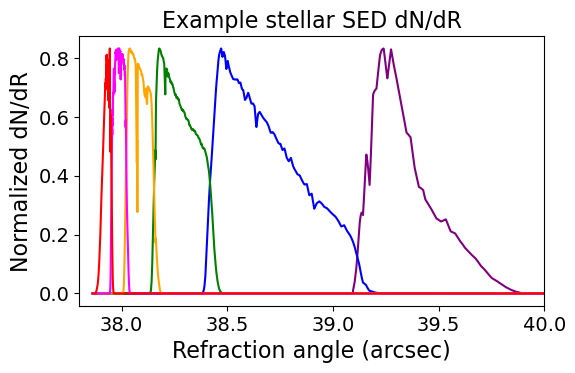

In [7]:

zenith = 45 #degrees
# dwvl = 0.1 #wavelength step
# wavelengths = np.arange(290, 1160, dwvl) 

#Matthew's atmospheric conditions
pressure=70.0,  # kPa
temperature=293.15,  # K
H2O_pressure=0.0,

#Pat and Josh's paper atmospheric conditions 
pressure=69.328
temperature=293.15
H2O_pressure=1.067




# SEA LEVEL
# pressure=101 #kPa
# temperature= 288.15 # K
# H2O_pressure= 1.067 # kPa

from utils import apply_DCR

# def apply_DCR(wave, filtered_data, zenith, pressure, temperature, H2O_pressure):
#     '''
#     wave - list of wavelength points
#     filtered_data - dictionary, keys: bands, items: list of flux throughputs for each SED as viewed in that band 

#     Takes in SED data with the filter throughputs already applied, returns refraction_angles (mapped from wave) and filtered_refracted_data (the flux density over refraction angles)

#     '''
#     dwvl = 0.1 #wavelength step
#     wave_temp = np.arange(290, 1160, dwvl)

#     #Get dR/dwavelength function
#     refraction = galsim.dcr.get_refraction(
#         wave_temp,
#         zenith_angle=zenith * galsim.degrees,
#         pressure=pressure,  # kPa
#         temperature=temperature,  # K
#         H2O_pressure=H2O_pressure,  # kPa
#         ) * 180 * 3600 / np.pi #convert from radians to arcsec

#     dR_dwvl = (refraction[1:] - refraction[0:-1])/dwvl
#     wavelengths_midpoints = wave_temp[0:-1] + dwvl/2
    
#     dRdwvl_func = interp1d(wavelengths_midpoints, dR_dwvl)

#     #Get the refraction angle of each passed in wavelength 
#     refraction_angles = galsim.dcr.get_refraction(
#             wave,
#             zenith_angle=zenith * galsim.degrees,
#             pressure=pressure,  # kPa
#             temperature=temperature,  # K
#             H2O_pressure=H2O_pressure,  # kPa
#             ) * 180 * 3600 / np.pi #convert from radians to arcsec
    
    
#     filtered_refracted_data = {} #dictionary which will store dN/dR 
    
#     for band, data in filtered_data.items():
#         filtered_refracted_data[band] = np.abs(data * wvl / dRdwvl_func(wvl)) # data * wvl to convert to relative photon flux density (from erg/s/cm^2/Angstrom)

#     return refraction_angles, filtered_refracted_data



refraction_angles, filtered_refracted_data = apply_DCR(wvl, filtered_data, zenith, pressure, temperature, H2O_pressure)
stellar_refraction_angles, stellar_filtered_refracted_data = apply_DCR(stellar_wvl, stellar_filtered_data, zenith, pressure, temperature, H2O_pressure)
flat_refraction_angles, flat_filtered_refracted = apply_DCR(wvl, flat_filtered, zenith, pressure, temperature, H2O_pressure)


fig = plt.figure(figsize = (6, 3.5))

#Examine the dN/dR results (galaxy)
for band, data in filtered_data.items():
    
    #example SED to plot
    example_refract_R = stellar_filtered_refracted_data[band][i]

    refraction_angles_ = flat_refraction_angles
    
    #plot normalized dNdR as a function of refraction
    plt.plot(refraction_angles_, np.abs(example_refract_R)/max(np.abs(example_refract_R))/ 1.2, color = colors[band]) 

    # edge_mask = np.abs(example_refract_R)/max(np.abs(example_refract_R))/ 1.2 > 0.0001
    # in_ = refraction_angles_[edge_mask]
    # print(band)
    # print(in_[0], in_[-1])
    # print(in_[0] - in_[-1])
    
plt.xlim(37.8, 40)
plt.xlabel('Refraction angle (arcsec)', fontsize = 16)
plt.ylabel('Normalized dN/dR', fontsize = 16)
plt.title(f'Example stellar SED dN/dR', fontsize = 16)
plt.tick_params(labelsize=14)
# plt.tight_layout()


In [8]:
#Calculate the mean and standard deviation of the refraction angle distributions for each of the SEDs in each filter

from utils import mean_and_std


means, stdevs = mean_and_std(refraction_angles, filtered_refracted_data, multi = True)
stellar_means, stellar_stdevs = mean_and_std(stellar_refraction_angles, stellar_filtered_refracted_data, multi = True)
flat_means, flat_stdevs = mean_and_std(refraction_angles, flat_filtered_refracted, multi = True)


# Print the galaxy results:
for band, means_ in means.items():
    print(f'{band} (galaxy average): R = {np.round(np.mean(means_), 4)} arcseconds') #, stdev = {np.round(np.mean(stdevs[band]), 4)}')
    # print(f'{band} (star average): R = {np.round(np.mean(stellar_means[band]), 4)} arcseconds') #, stdev = {np.round(np.mean(stdevs[band]), 4)}')
    # print(f'{band} (flat): R = {np.round(flat_stdevs[band][0], 4)} arcseconds') #, stdev = {np.round(np.mean(stdevs[band]), 4)}')


# Print the expected Delta R (assuming the star sample is representative of the calibration sample):
for band, means_ in means.items():
    gal_R = np.mean(means_)
    star_R = np.mean(stellar_means[band])
    
    print(f'DCR Magnitude {band} (Avg Gal - Avg Star): {np.round((gal_R - star_R), 3)} arcseconds') #, stdev = {np.round(np.mean(BB_stdev[band]), 4)}')


u (galaxy average): R = 39.3721 arcseconds
g (galaxy average): R = 38.6892 arcseconds
r (galaxy average): R = 38.2714 arcseconds
i (galaxy average): R = 38.083 arcseconds
z (galaxy average): R = 37.9883 arcseconds
y (galaxy average): R = 37.9278 arcseconds
DCR Magnitude u (Avg Gal - Avg Star): 0.031 arcseconds
DCR Magnitude g (Avg Gal - Avg Star): 0.005 arcseconds
DCR Magnitude r (Avg Gal - Avg Star): -0.007 arcseconds
DCR Magnitude i (Avg Gal - Avg Star): -0.004 arcseconds
DCR Magnitude z (Avg Gal - Avg Star): -0.002 arcseconds
DCR Magnitude y (Avg Gal - Avg Star): -0.001 arcseconds


DCR Magnitude u (Avg Gal - 5000 K BB): 0.02 arcseconds
DCR Magnitude g (Avg Gal - 5000 K BB): 0.019 arcseconds
DCR Magnitude r (Avg Gal - 5000 K BB): -0.004 arcseconds
DCR Magnitude i (Avg Gal - 5000 K BB): -0.003 arcseconds
DCR Magnitude z (Avg Gal - 5000 K BB): -0.001 arcseconds
DCR Magnitude y (Avg Gal - 5000 K BB): -0.001 arcseconds


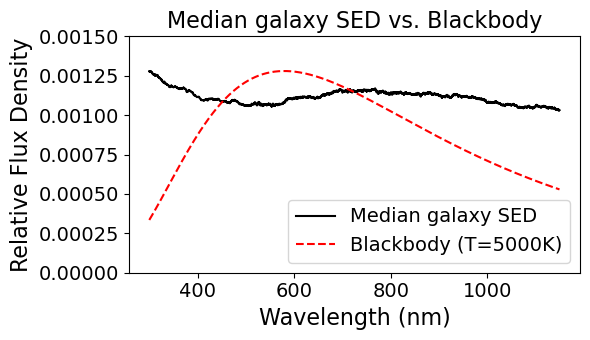

In [9]:
# Now lets compare these refraction results to a point source with a 5000 K blackbody SED (approximation of a calibration star).

BB_SED = BB(wvl * 10 ,temp = 5000, scale = 1) #BB expects wavelength in Angstroms, so convert from nm by multiplying by 10

BB_filtered = {band: apply_filter(wvl, BB_SED, band  = band) for band in 'ugrizy'}


BB_refraction_angles, BB_filtered_refracted = apply_DCR(wvl, BB_filtered, zenith, pressure, temperature, H2O_pressure)

BB_mean, BB_stdev = mean_and_std(BB_refraction_angles, BB_filtered_refracted, multi = False)

for band in 'ugrizy':
    gal_R = np.mean(means[band])
    BB_R = BB_mean[band]
    # print(f'{band} (5000 K blackbody): mean = {np.round(np.mean(means_), 4)}, stdev = {np.round(np.mean(BB_stdev[band]), 4)}')
    print(f'DCR Magnitude {band} (Avg Gal - 5000 K BB): {np.round((gal_R - BB_R), 3)} arcseconds') #, stdev = {np.round(np.mean(BB_stdev[band]), 4)}')


# plot the average galaxy SED against the BB for reference:
plt.figure(figsize = (6, 3.5))
plt.plot(wvl, average_SED, 'k-', label = 'Median galaxy SED')
plt.plot(wvl, BB(wvl * 10, 5000, 1e-9), 'r--', label = 'Blackbody (T=5000K)')
plt.xlabel('Wavelength (nm)', fontsize = 16)
plt.ylim(0, 0.0015)
plt.ylabel('Relative Flux Density', fontsize = 16)
plt.title('Median galaxy SED vs. Blackbody', fontsize = 16)
plt.legend(fontsize = 14)
plt.tick_params(labelsize=14)
plt.tight_layout()  


In [10]:
# Calculate the relative magnitudes for each SED for color comparisons

def synth_fnu(wl, Flam, band, wl_units = 'nm'):
    '''
    Calculates a synthetic flux
    wl - wavelength array in apropriate units (see wl_units)
    Flam - SED (unfiltered) in in erg/cm^2/s/A
    wl_units - 'nm' or 'A'
    '''
    
    if wl_units == 'nm':
        wl_A = wl * 10
        wl_nm = wl
    elif wl_units == 'A':
        wl_A = wl
        wl_nm = wl/10

    filter_file = f'filter_files/total_{band}.dat'
    filter_band = np.loadtxt(filter_file).T #filter_band[0] -> wavelengths, filter_band[1] -> filter pass fraction

    T = interp1d(filter_band[0], filter_band[1])(wl_nm)

    num = np.trapezoid(Flam * T * wl_A, wl_A)
    den = np.trapezoid(T / wl_A, wl_A)
    
    return num / den   # proportional to <f_nu>

    
# for band in filter_labels:
#     filtered_data[band]= apply_filter(wvl, SEDs, band)
#     stellar_filtered_data[band]= apply_filter(stellar_wvl, stellar_SEDs, band)
#     flat_filtered[band] = apply_filter(wvl, flatSED, band)
#     plt.plot(wvl, stellar_filtered_data[band][i] * wvl, color = colors[band])


Flux = {}
stellar_Flux = {}
BB_Flux = {}

for band in filter_labels:
    Flux[band] = [synth_fnu(wvl, SED_, band, wl_units = 'nm') for SED_ in SEDs]
    stellar_Flux[band] = [synth_fnu(wvl, SED_, band, wl_units = 'nm') for SED_ in stellar_SEDs[0:1000]]
    BB_Flux[band] = synth_fnu(wvl, BB_SED, band, wl_units = 'nm')

# gi_color = -2.5 * np.log10(BB_Flux['g'] / BB_Flux['i'])
# print('g-i color of reference BB: ', np.round(gi_color, 4))

# i = 1

# print(stellar_temps[i])

# gi_color = -2.5 * np.log10(stellar_Flux['g'][i] / stellar_Flux['i'][i])
# print('g-i color of reference BB: ', np.round(gi_color, 4))



# plt.plot(wvl, stellar_SEDs[i] , 'k', label = f'SED index: {i}')
# plt.plot(wvl, BB(wvl * 10 ,temp = stellar_temps[i], scale = 1e-9), 'r--')

In [11]:
#Aside: Matthew's method for calculating the total refraction across a band

'''
def calculate_filter_refractions(filter_files, directory, airmasses, dcr = True, cutoff = 8005):
    
    wavelengths = np.linspace(300, 1100, 8000)

    #get a list of zeniths from the airmasses
    zeniths = []
    for airmass in airmasses:
        if airmass > 0:
            zeniths.append(np.arccos(1 / airmass))
        else:
            zeniths.append(np.nan)  # handle zero or negative airmass values
    zeniths = np.degrees(zeniths) * u.deg
    # print(zeniths)

    #For each zenith, create a list of refractions mapped from the wavelengths
    gs_refractions = np.zeros((len(zeniths), len(wavelengths)))
    for i, zenith in enumerate(zeniths):
        gs_refraction = 3600 * np.rad2deg(galsim.dcr.get_refraction(
            wavelengths,
            zenith_angle=zenith.to_value(u.deg) * galsim.degrees,
            # pressure=70.0,  # kPa
            # temperature=293.15,  # K
            # H2O_pressure=0.0,  # kPa
            pressure=69.328,
            temperature=293.15,
            H2O_pressure=1.067,
        ))
        gs_refractions[i, :] = gs_refraction


    #For each filter, find the left and right wavelength and cross reference those to the gs_refractions table above to get the differential refraction
    filter_refractions = []
    refraction_centers = []

    for i, filter_file in enumerate(filter_files):
        #Seems like this information about the filters should just be saved once and referred back to
        data = read_filter_data_from_directory(directory, filter_file)
        wavelength = data[:(cutoff + 1), 0]
        throughput = data[:(cutoff + 1), 1]
        fwhm, left_wavelength, right_wavelength, left_idx, right_idx = calculate_fwhm(wavelength, throughput)
        
        left_idx_new = find_nearest_index(wavelengths, left_wavelength)
        right_idx_new = find_nearest_index(wavelengths, right_wavelength)

        refraction_left = gs_refractions[:, left_idx_new]
        refraction_right = gs_refractions[:, right_idx_new]
        differential_refractions = abs(refraction_left - refraction_right) if dcr else np.zeros_like(airmasses)
        refraction_center = min([refraction_left, refraction_right]) + differential_refractions/2
        filter_refractions.append(differential_refractions)
        refraction_centers.append(refraction_center)
    return filter_refractions, refraction_centers

def find_nearest_index(array, value):
    return (np.abs(array - value)).argmin()

def calculate_fwhm(wavelength, throughput, cutoff = 8005):
    max_index = np.argmax(throughput)
    half_max = throughput[max_index] / 10 #may change to actual half maximum. This will calculate the range of the filter
    
    # left index where throughput drops below half max
    left_idx = max_index
    for i in range(max_index, 0, -1):
        if throughput[i] < half_max:
            left_idx = i
            break
    
    # right index where throughput drops below half max
    right_idx = 0
    j = cutoff #throughput becomes zeros past the value of cutoff = 8005
    while throughput[j] <= half_max:
            right_idx = j
            j -= 1
            if throughput[j] > half_max:
                break
    
    fwhm = wavelength[right_idx] - wavelength[left_idx]
    return fwhm, wavelength[left_idx], wavelength[right_idx], left_idx, right_idx

def read_filter_data_from_directory(directory, filter_file):
    file_path = os.path.join(directory, filter_file)
    data = np.loadtxt(file_path)
    return data


directory = 'filter_files' 
filter_files = ['total_u.dat', 'total_g.dat', 'total_r.dat', 'total_i.dat', 'total_z.dat', 'total_y.dat']

filter_refractions, refraction_centers = calculate_filter_refractions(filter_files, directory, [float(1/np.cos(zenith*u.deg))])

for i, filt in enumerate(filter_files):
    # print(filt,'full width', filter_refractions[i])
    print(filt , 'stdev: ', filter_refractions[i]/np.sqrt(12))

'''

"\ndef calculate_filter_refractions(filter_files, directory, airmasses, dcr = True, cutoff = 8005):\n\n    wavelengths = np.linspace(300, 1100, 8000)\n\n    #get a list of zeniths from the airmasses\n    zeniths = []\n    for airmass in airmasses:\n        if airmass > 0:\n            zeniths.append(np.arccos(1 / airmass))\n        else:\n            zeniths.append(np.nan)  # handle zero or negative airmass values\n    zeniths = np.degrees(zeniths) * u.deg\n    # print(zeniths)\n\n    #For each zenith, create a list of refractions mapped from the wavelengths\n    gs_refractions = np.zeros((len(zeniths), len(wavelengths)))\n    for i, zenith in enumerate(zeniths):\n        gs_refraction = 3600 * np.rad2deg(galsim.dcr.get_refraction(\n            wavelengths,\n            zenith_angle=zenith.to_value(u.deg) * galsim.degrees,\n            # pressure=70.0,  # kPa\n            # temperature=293.15,  # K\n            # H2O_pressure=0.0,  # kPa\n            pressure=69.328,\n            tempe

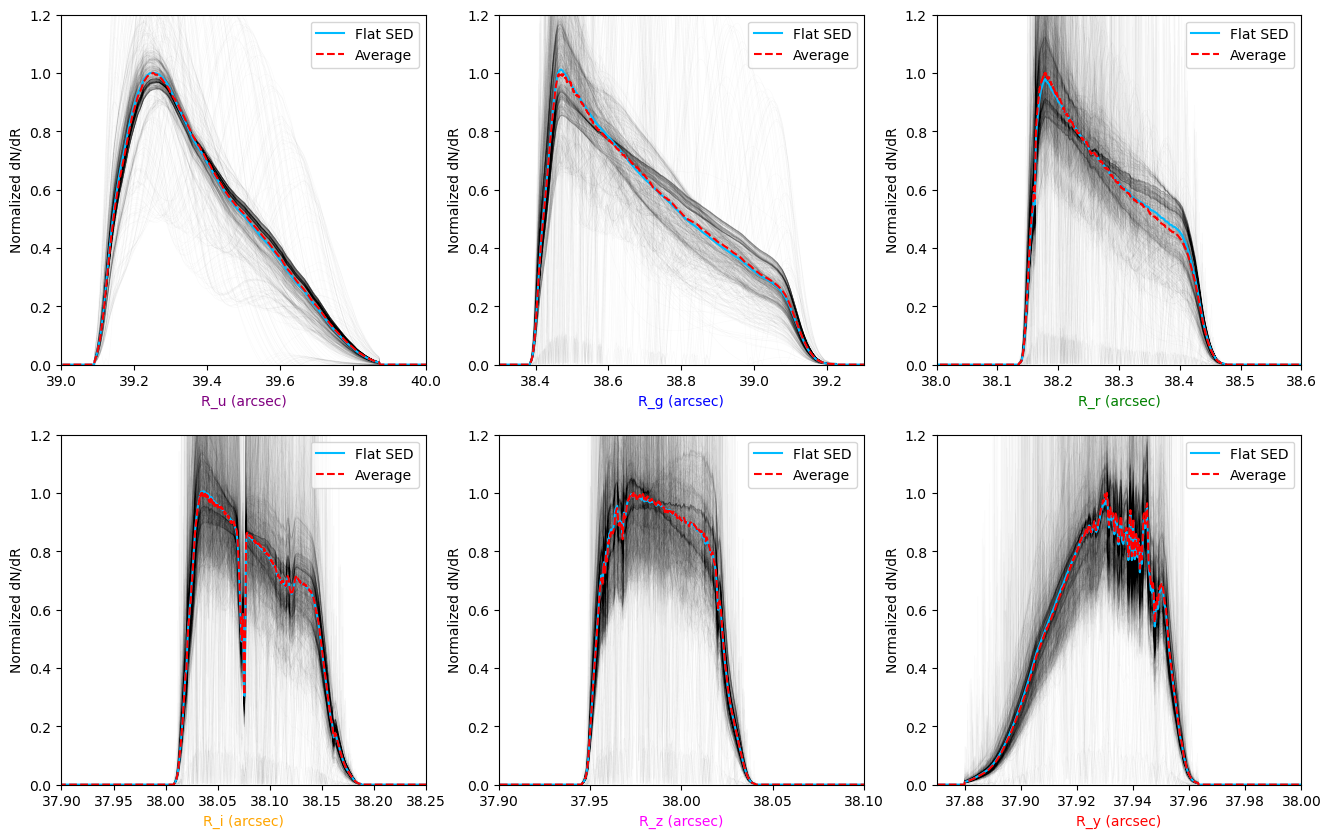

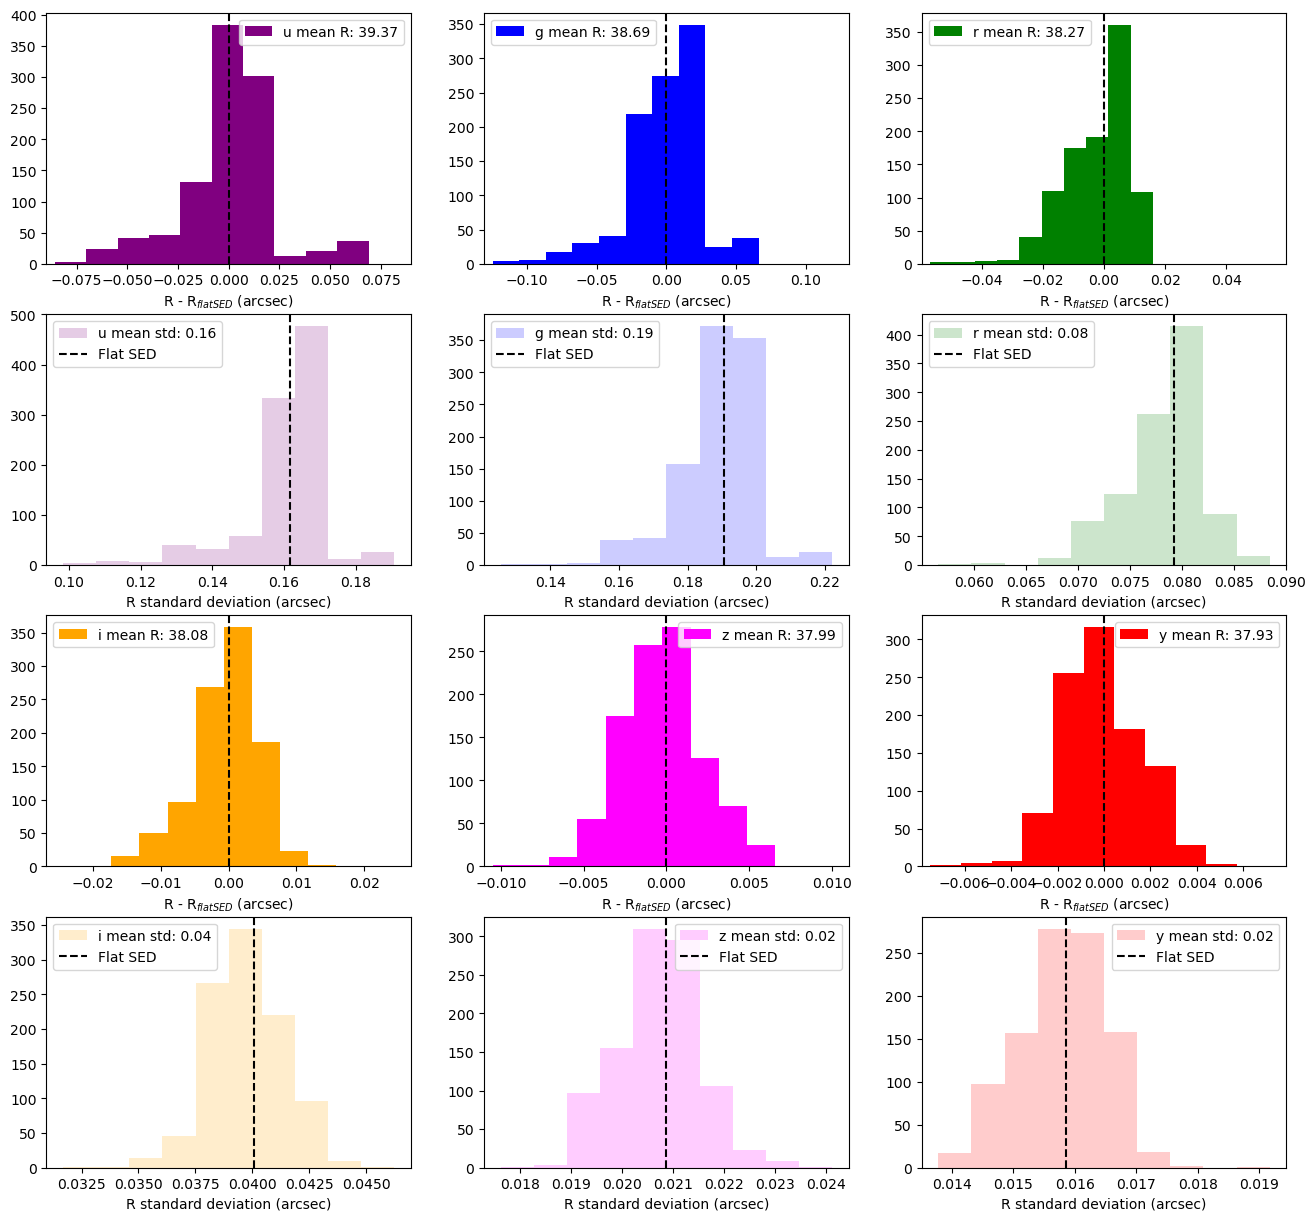

In [12]:
#Summary Plots

#define some axis limits for the dN/dR plots
#zenith = 35
mins = [27.25, 26.8, 26.6, 26.55, 26.5, 26.5]
maxs = [28, 27.5, 27, 26.8, 26.7, 26.6]

#zenith = 45
mins = [39, 38.3, 38, 37.9, 37.9, 37.87]
maxs = [40, 39.3, 38.6, 38.25, 38.1, 38]


def plot_refraction_distributions(refraction_angles, filtered_refracted_data, means, stdevs, mean_flatdist, stdev_flatdist):

    fig1, ax1 = plt.subplots(2, 3, figsize = (16, 10))

    fig2, ax2 = plt.subplots(4, 3, figsize = (16, 15))

    for i, band in enumerate(filter_labels):
        

        n = i // 3
        m = i % 3


        normalizing_factor  = np.max(filtered_refracted_data[band][-1] / np.sum(filtered_refracted_data[band][-1]))

        # -- plot all distributions on top of each other with a small alpha 
        for dist in filtered_refracted_data[band][:-1]:
            # normalized = np.abs(dist)/max(np.abs(dist))/1.2
            # normalized = np.abs(dist) / np.sum(np.abs(dist)) / np.max(avg_dNdR[band])
            # summed += normalized
            ax1[n, m].plot(refraction_angles, dist / np.sum(dist) / normalizing_factor, 'k', linewidth = 0.5, alpha = 0.02)

        # -- Flat distribution plot
        ax1[n, m].plot(flat_refraction_angles, flat_filtered_refracted[band][0] / np.sum(flat_filtered_refracted[band][0]) / normalizing_factor , '-', linewidth = 1.5, color = "#00BBFF", label = f'Flat SED')

        # -- test plot
        # ax1[n, m].plot(refraction_angles, filtered_refracted_data[band][-1]/max(filtered_refracted_data[band][-1])/1.2 , 'y-', label = f'flat sed')
        # ax1[n, m].plot(refraction_angles, filtered_refracted_data[band][-1]/np.sum(filtered_refracted_data[band][-1]) / np.max(avg_dNdR[band] ) , '-', linewidth = 1.5, color = "#00BBFF", label = f'Flat SED')
        
        # -- plot the average distribution
        ax1[n, m].plot(refraction_angles, filtered_refracted_data[band][-1] / np.sum(filtered_refracted_data[band][-1]) / normalizing_factor, 'r--', linewidth = 1.5,  label = f'Average')

        ax1[n, m].legend(loc = 'upper right')
        ax1[n, m].set_xlim(mins[i], maxs[i])
        ax1[n, m].set_ylim(0, 1.2)
        ax1[n, m].set_xlabel(f'R_{band} (arcsec)', color = colors[band])
        ax1[n, m].set_ylabel('Normalized dN/dR')
        


        # --- plot a histogram of the means and standard deviations for each filter

        # -- log plot of the squared deviations from the mean
        # ax2[n*2, m].hist(np.log10((means[band][:-1] - np.mean(means[band][:-1]))**2), 50, label = f'{band} refraction mean: {np.round(np.mean(means[band]), 2)}', color = colors[band])

        # -- regular histogram of the 1st moment shifts
        ax2[n*2, m].hist(means[band] - mean_flatdist[band][0] , label = f'{band} mean R: {np.round(np.mean(means[band]), 2)}', color = colors[band])

        ax2[n*2, m].axvline(0, color = 'k', linestyle = '--')

        ax2[n*2, m].legend()
        ax2[n*2, m].set_xlabel(r'R - R$_{flat SED}$ (arcsec)')
        ax2[n*2, m].set_xlim(-np.max(np.abs(means[band] - mean_flatdist[band][0]))*1.05, np.max(np.abs(means[band] - mean_flatdist[band][0]))*1.05)

        # -- plot distribition of standard deviations
        ax2[n*2 + 1, m].hist(stdevs[band], label = f'{band} mean std: {np.round(np.mean(stdevs[band]), 2)}', color = colors[band], alpha = 0.2)

        ax2[n*2 + 1, m].axvline(stdev_flatdist[band][0], color = 'k', linestyle = '--', label = 'Flat SED')

        # ax2[n*2 + 1, m].plot(filter_refractions[i]/np.sqrt(12), 5, 'ko') #flat dN/dR stdev
        ax2[n*2 + 1, m].legend()
        ax2[n*2 + 1, m].set_xlabel('R standard deviation (arcsec)')
        # ax2[n*2 + 1, m].set_xlim(0, filter_refractions[i]/np.sqrt(12) *1.05)
    
    
    # fig1.savefig(f'refraction_dist_plots/all.png')
    # fig1.savefig(f'refraction_dist_plots/all.pdf')


    # fig2.savefig(f'refraction_dist_plots/all_histograms.png')
    # fig2.savefig(f'refraction_dist_plots/all_histograms.pdf')

    return

# --- Plot the results (galaxy) ---
plot_refraction_distributions(refraction_angles, filtered_refracted_data, means, stdevs, flat_means, flat_stdevs)

# --- Plot the results (stellar) ---
# plot_refraction_distributions(stellar_refraction_angles, stellar_filtered_refracted_data, stellar_means, stellar_stdevs, flat_means, flat_stdevs)


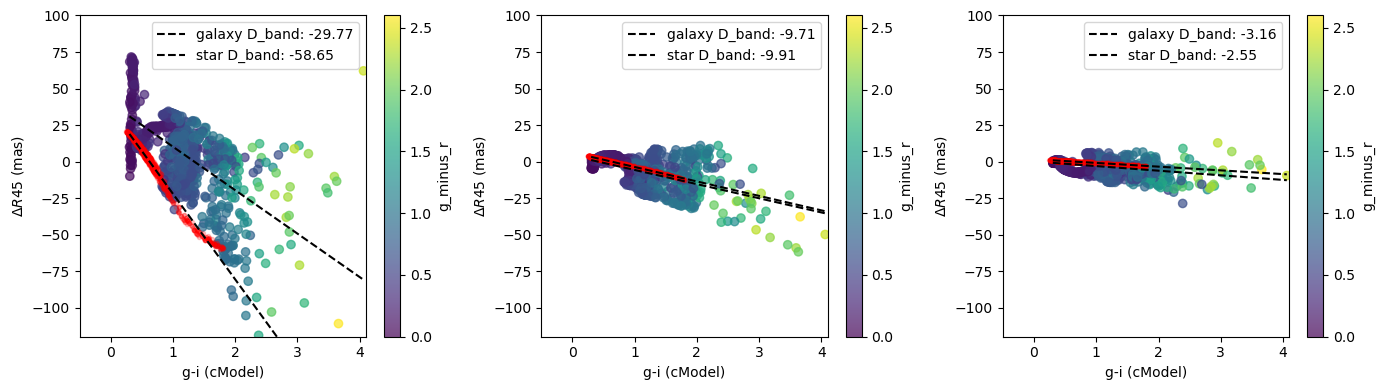

In [13]:
#Single Color corrections prediction plots

from scipy.optimize import curve_fit


gi_color = -2.5 * np.log10(np.array(Flux['g']) / np.array(Flux['i']))
gr_color = -2.5 * np.log10(np.array(Flux['g']) / np.array(Flux['r']))
stellar_gi_color = -2.5 * np.log10(np.array(stellar_Flux['g']) / np.array(stellar_Flux['i']))


# linear fit
def lin(x, a, c):
    return a * (x + c)


import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(14, 4), sharex=True)

for i, band in enumerate('gri'):
    y = (means[band] - np.mean(stellar_means[band])) * 1000
    x = gi_color
    cmap = gr_color


    sc = ax[i].scatter(x, y, c = cmap, alpha  = 0.7, vmin = 0, vmax = 2.6)#, label = 'galaxies')

    
    y_stars = (stellar_means[band][0:1000] - np.mean(stellar_means[band])) * 1000
    x_stars = stellar_gi_color

    ax[i].plot(x_stars, y_stars, '.', c = 'r',alpha = 0.2)#, label = 'stars')
    
    popt, pcov = curve_fit(lin, x, y, p0 = [0, 0])# , sigma = np.abs(yerr))
    perr = np.sqrt(pcov[0,0])
    # print(popt)
    
    x_temp = np.linspace(min(x), max(x))
    ax[i].plot(x_temp, lin(x_temp, *popt),'k--', label = f'galaxy D_band: {np.round(popt[0],2)}') # +- {np.round(perr, 2)}')

    
    
    popt, pcov = curve_fit(lin, x_stars, y_stars, p0 = [0, 0])# , sigma = np.abs(yerr))
    perr = np.sqrt(pcov[0,0])
    # print(popt)
    
    x_temp = np.linspace(min(x), max(x))
    ax[i].plot(x_temp, lin(x_temp, *popt),'k--', label = f'star D_band: {np.round(popt[0],2)} ') #+- {np.round(perr, 2)}')

    
    popt, pcov = curve_fit(lin, np.append(x, x_stars), np.append(y, y_stars), p0 = [0, 0])# , sigma = np.abs(yerr))
    perr = np.sqrt(pcov[0,0])
    # print(popt)
    
    x_temp = np.linspace(min(x), max(x))
    # ax[i].plot(x_temp, lin(x_temp, *popt),'r--', label = f'combined D_band: {np.round(popt[0],2)} ') #+- {np.round(perr, 2)}')


    ax[i].set_xlim(-0.5, 4.1)
    ax[i].set_ylim(-120, 100)

    plt.colorbar(sc, ax = ax[i], label = 'g_minus_r')
    ax[i].set_xlabel('g-i (cModel)')
    ax[i].set_ylabel(r'$\Delta R45$ (mas)')
    
    ax[i].legend(loc = 'upper right')
    # plt.show()
    # plt.close()
    

plt.tight_layout()

In [14]:
# --- Calculate the mean wavelength E[lambda] within each band for each SED


wvl_means, wvl_stdevs = mean_and_std(wvl, filtered_data, multi = True)
stellar_wvl_means, stellar_wvl_stdevs = mean_and_std(stellar_wvl, stellar_filtered_data, multi = True)
flat_wvl_means, flat_wvl_stdevs = mean_and_std(wvl, flat_filtered, multi = True)


/home/msredden/DifferentialCR/utils.py:124: RuntimeWarning: invalid value encountered in sqrt
  stdevs[band] = np.sqrt(np.trapezoid(x = x_array, y = weights * (x_transpose - mean[:, np.newaxis])**2, axis=1) / np.trapezoid(x = x_array, y = weights, axis=1))


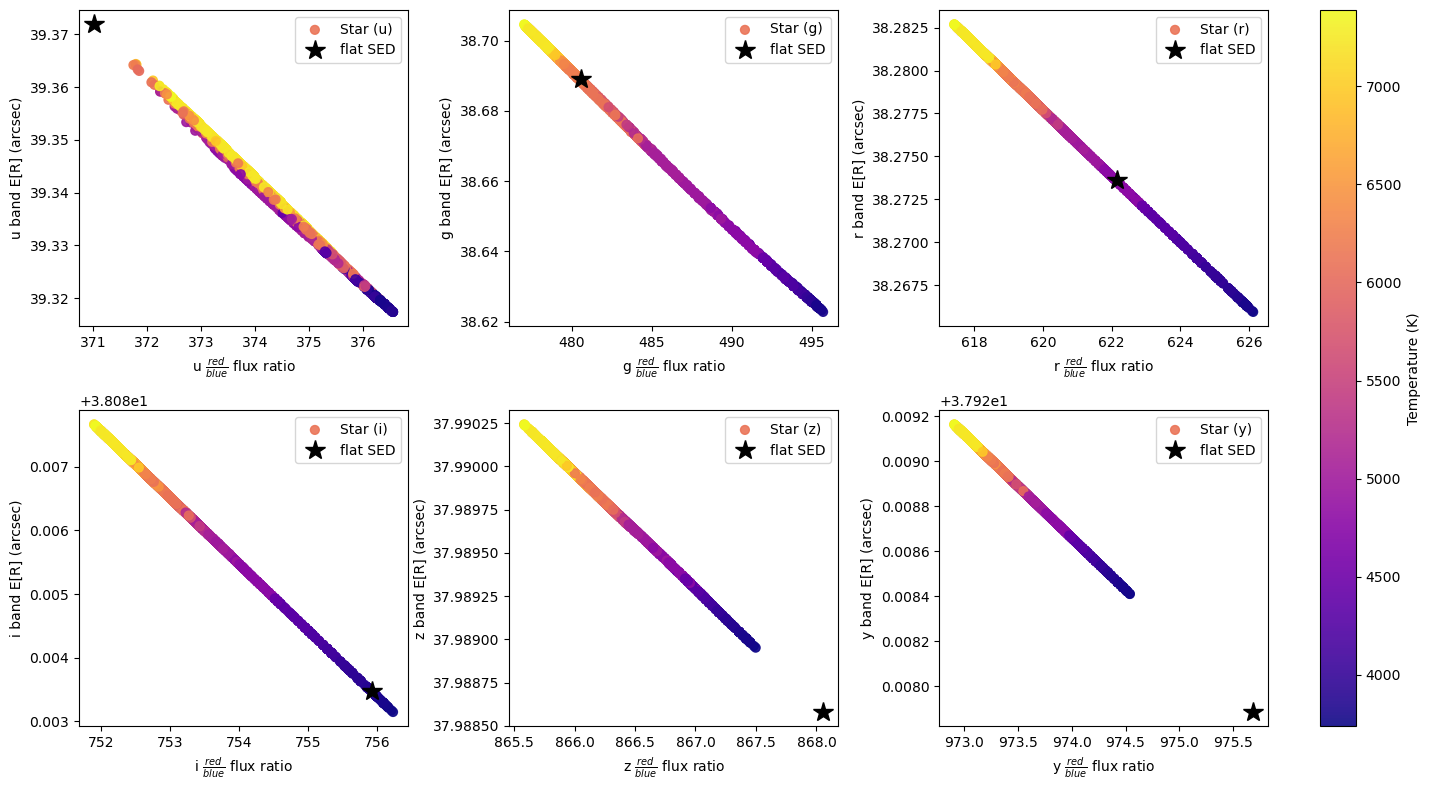

In [15]:
# Create a scatter plot of the 1st moment DCR shift as a function of the SED slope (within a band) 

flux_ratios = {}

band_edges = {
    'u' : [320, 400],
    'g' : [400, 552],
    'r' : [552, 691],
    'i' : [691, 818],
    'z' : [818, 922],
    'y' : [950, 1080]
} #band endges from the LSST Science Book https://www.lsst.org/sites/default/files/docs/sciencebook/SB_2.pdf

band_edges = {
    'u' : [338, 395],
    'g' : [405, 552],
    'r' : [553, 690],
    'i' : [690, 817],
    'z' : [818, 920],
    'y' : [920, 1010]
} 


# --- Stellar SEDs, plotting slope or mean wavelength vs E[R]

fig, ax = plt.subplots(2, 3, figsize = (14, 8))
for i, band in enumerate(filter_labels):

    # # --- X data: Stellar SED slopes versus DCR 1st moment:

    left, right = band_edges[band]
    mask = (stellar_wvl >= left) & (stellar_wvl <= right)
    band_wvl = stellar_wvl[mask]
    band_SEDs = stellar_SEDs[:, mask]

    l_edge = np.mean(band_SEDs[:, 0:10], axis = 1)
    r_edge = np.mean(band_SEDs[:, -10:], axis = 1)
    flux_ratio = r_edge/l_edge  #flux ratio blue/red

    flux_ratios[band] = np.array(flux_ratio)
    x_data = flux_ratio[:-1] #clip the last item (average SED)

    flat_x = [1] #by definition, a flat SED should have a ratio of 1

    # --- X data: Mean wavelength 
    x_data = stellar_wvl_means[band][:-1]
    flat_x = flat_wvl_means[band]


    # -- Scatter plot of slope vs DCR 1st moment
    # fig = plt.figure(figsize = (6, 4))
    sc = ax[i // 3, i % 3].scatter(x_data, stellar_means[band][:-1], c = stellar_temps, cmap = 'plasma', s = 40, alpha = 0.9, label = f'Star ({band})')
    ax[i // 3, i % 3].plot(flat_x, flat_means[band],'*', color = "#000000", markersize = 15, label = 'flat SED')
    
    ax[i // 3, i % 3].set_xlabel(rf'{band} $\frac{{red}}{{blue}}$ flux ratio')
    # ax[i // 3, i % 3].set_xlabel(rf'{band} band E[$\lambda$] (nm)')
    ax[i // 3, i % 3].set_ylabel(fr'{band} band E[R] (arcsec)')
    ax[i // 3, i % 3].legend()

    # # -- Scatter plot of temperature vs DCR 1st moment
    # plt.scatter(stellar_temps, stellar_means[band])
    # plt.xlabel('Temperature (K)')
    # plt.ylabel(fr'{band} band DCR 1st moment (arcsec)')
    # plt.show()
    # plt.close()

    # # -- Example SED and slope line
    # i = 100
    # plt.plot(band_wvl, band_SEDs[i] - band_SEDs[i][0], 'k-')
    # plt.plot([left, right], [0, band_slopes[i]*(right - left)], 'r--')

    # plt.show()
    # plt.close()

fig.tight_layout()
cbar = fig.colorbar(sc, ax = ax, orientation="vertical", fraction=0.046, pad=0.04)
cbar.set_label("Temperature (K)")

plt.show()
plt.close()

23
1
2
4
5
8


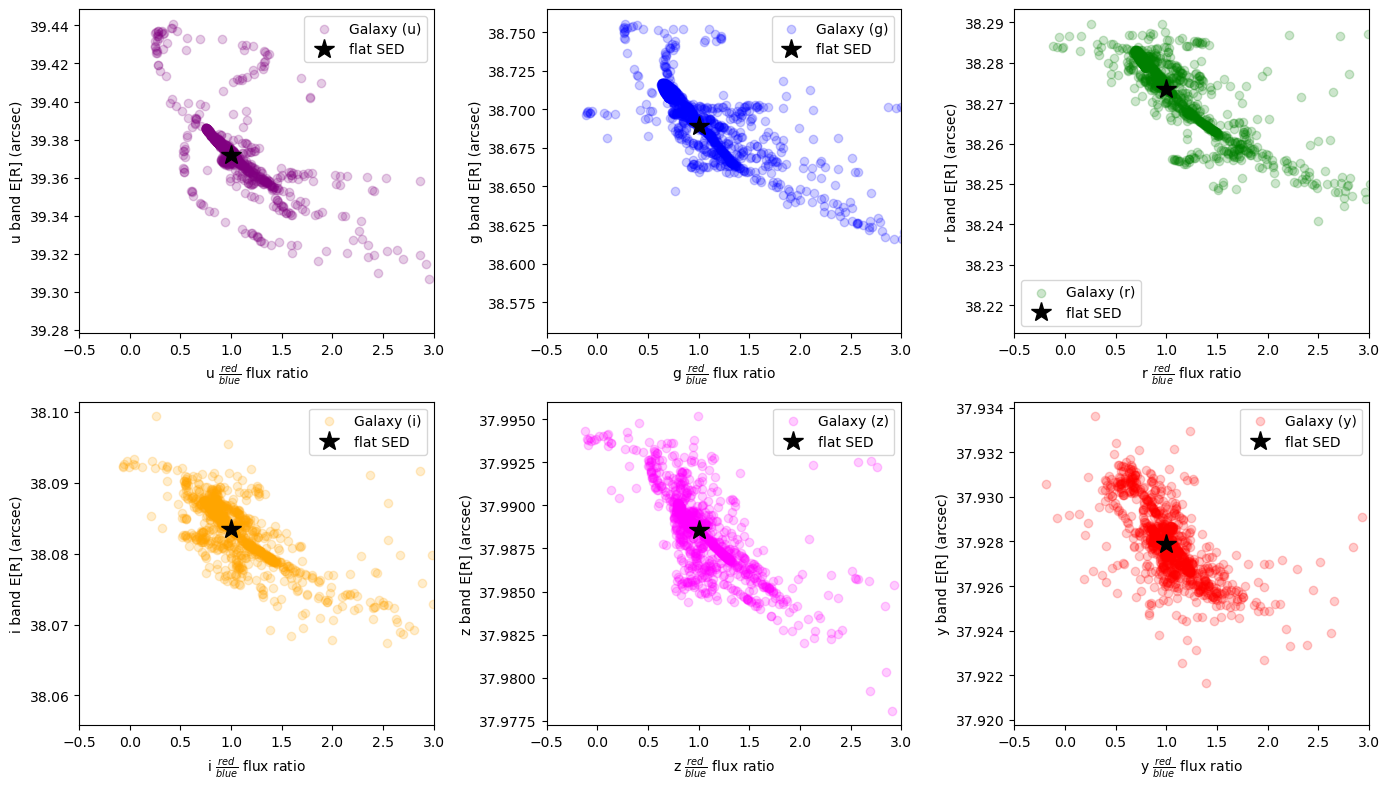

In [16]:


# ---- Galaxy SEDs, plotting slope or mean wavelength vs E[R]

fig, ax = plt.subplots(2, 3, figsize = (14, 8))

for i, band in enumerate(filter_labels):

    # --- X data: Galaxy SED flux ratio 
    left, right = band_edges[band]
    mask = (wvl >= left) & (wvl <= right)
    band_wvl = wvl[mask]
    band_SEDs = SEDs[:, mask]

    l_edge = np.mean(band_SEDs[:, 0:10], axis = 1)
    r_edge = np.mean(band_SEDs[:, -10:], axis = 1)
    print(np.sum(l_edge < 0))
    flux_ratio = r_edge/l_edge  #flux ratio blue/red

    x_data = flux_ratio[:-1]
    flat_x = [1]


    # --- X data: Mean wavelength 
    # x_data = wvl_means[band][:-1]
    # flat_x = flat_wvl_means[band]


    # -- Scatter plot of slope vs DCR 1st moment
    ax[i // 3, i % 3].scatter(x_data, means[band][:-1], color = colors[band], alpha = 0.2, label = f'Galaxy ({band})')
    ax[i // 3, i % 3].plot(flat_x, flat_means[band],ls = '',  marker = '*', color = "#000000", markersize = 15, label = 'flat SED')

    ax[i // 3, i % 3].set_xlim(-0.5, 3)
    ax[i // 3, i % 3].set_xlabel(rf'{band} $\frac{{red}}{{blue}}$ flux ratio')
    # ax[i // 3, i % 3].set_xlabel(rf'{band} band E[$\lambda$] (nm)')
    ax[i // 3, i % 3].set_ylabel(fr'{band} band E[R] (arcsec)')
    ax[i // 3, i % 3].legend()
   

    # # -- Example SED and slope line
    # i = 1
    # plt.plot(band_wvl, band_SEDs[i] - band_SEDs[i][0], 'k-')
    # plt.plot([left, right], [0, band_slopes[i]*(right - left)], 'r--')

    # plt.show()
    # plt.close()



plt.tight_layout()
plt.show()
plt.close()


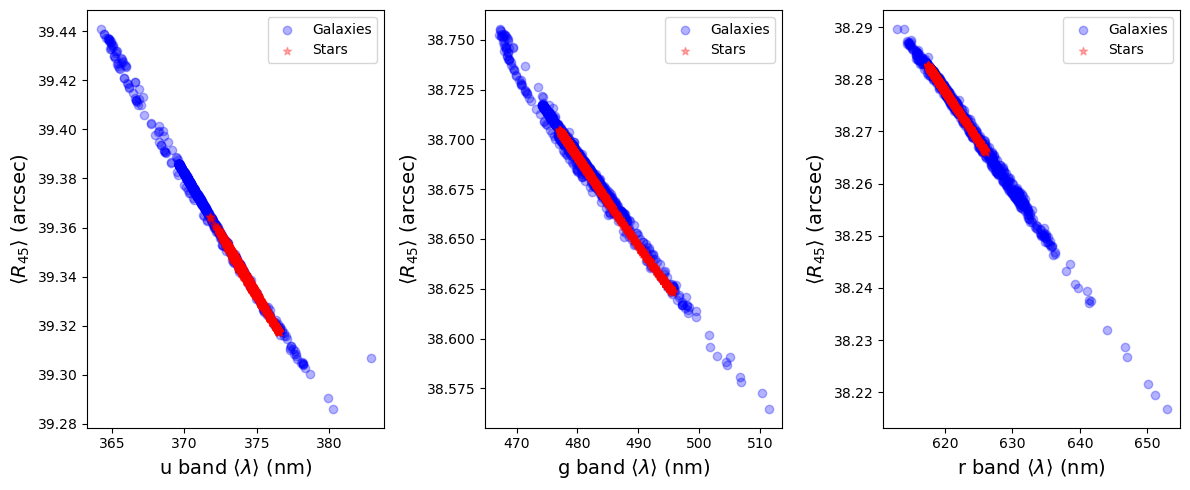

In [17]:
# Create a scatter plot of the 1st moment DCR shift as a function of the SED slope (within a band) 

flux_ratios = {}

band_edges = {
    'u' : [320, 400],
    'g' : [400, 552],
    'r' : [552, 691],
    'i' : [691, 818],
    'z' : [818, 922],
    'y' : [950, 1080]
} #band endges from the LSST Science Book https://www.lsst.org/sites/default/files/docs/sciencebook/SB_2.pdf

band_edges = {
    'u' : [338, 395],
    'g' : [405, 552],
    'r' : [553, 690],
    'i' : [690, 817],
    'z' : [818, 920],
    'y' : [920, 1010]
} 


# --- Stellar SEDs, plotting slope or mean wavelength vs E[R]

fig, ax = plt.subplots(1, 3, figsize = (12, 5))
for i, band in enumerate(['u', 'g', 'r']):

     # --- X data: Mean wavelength 
    x_data = wvl_means[band][:-1]
    flat_x = flat_wvl_means[band]


    # -- Scatter plot of slope vs DCR 1st moment
    ax[i % 3].scatter(x_data, means[band][:-1], marker = 'o', color = 'b', alpha = 0.3, label = f'Galaxies')

    # # --- X data: Stellar SED slopes versus DCR 1st moment:

    left, right = band_edges[band]
    mask = (stellar_wvl >= left) & (stellar_wvl <= right)
    band_wvl = stellar_wvl[mask]
    band_SEDs = stellar_SEDs[:, mask]

    l_edge = np.mean(band_SEDs[:, 0:10], axis = 1)
    r_edge = np.mean(band_SEDs[:, -10:], axis = 1)
    flux_ratio = r_edge/l_edge  #flux ratio blue/red

    flux_ratios[band] = np.array(flux_ratio)
    x_data = flux_ratio[:-1] #clip the last item (average SED)

    flat_x = [1] #by definition, a flat SED should have a ratio of 1

    # --- X data: Mean wavelength 
    x_data = stellar_wvl_means[band][:-1]
    flat_x = flat_wvl_means[band]


    # -- Scatter plot of slope vs DCR 1st moment
    # fig = plt.figure(figsize = (6, 4))
    sc = ax[i % 3].scatter(x_data, stellar_means[band][:-1], marker = '*', color = 'r', alpha = 0.3, label = f'Stars')
    
    # ax[i % 3].set_xlabel(rf'{band} $\frac{{red}}{{blue}}$ flux ratio')
    # # ax[i % 3].set_xlabel(rf'{band} band E[$\lambda$] (nm)')
    # ax[i % 3].set_ylabel(fr'{band} band E[R] (arcsec)')
    # ax[i % 3].legend()




    # ax[i % 3].set_xlim(-0.5, 3)
    # ax[i % 3].set_xlabel(rf'{band} $\frac{{red}}{{blue}}$ flux ratio')
    ax[i % 3].set_xlabel(rf'{band} band $ \langle \lambda \rangle$ (nm)', fontsize = 14)
    ax[i % 3].set_ylabel(fr'$\langle R_{{45}} \rangle$ (arcsec)', fontsize = 14)
    ax[i % 3].legend()


fig.tight_layout()
# cbar = fig.colorbar(sc, ax = ax, orientation="vertical", fraction=0.046, pad=0.04)
# cbar.set_label("Temperature (K)")

plt.show()
plt.close()